# Лабораторная работа №6: Бутстрап-методы и доверительные интервалы

## Теоретическое введение

### 1. Экспоненциальное распределение

Экспоненциальное (показательное) распределение часто используется для моделирования времени ожидания между событиями в пуассоновском процессе.

**Функция плотности:**
$$f(x; \lambda) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Математическое ожидание:**
$$M[X] = \frac{1}{\lambda}$$

**Дисперсия:**
$$D[X] = \frac{1}{\lambda^2}$$

В данной работе задано $M[X] = 5$, следовательно:
$$\lambda = \frac{1}{M[X]} = 0.2$$

### 2. Доверительные интервалы для математического ожидания

#### 2.1 Параметрический метод (при известной дисперсии)

Если генеральная совокупность распределена нормально или объём выборки достаточно велик (для применения ЦПТ), доверительный интервал для математического ожидания имеет вид:

$$\left( \bar{X} - \frac{\sigma}{\sqrt{n}} \cdot z_{1-\alpha/2}, \quad \bar{X} + \frac{\sigma}{\sqrt{n}} \cdot z_{1-\alpha/2} \right)$$

где $z_{1-\alpha/2}$ — квантиль стандартного нормального распределения уровня $1-\alpha/2$.

Для экспоненциального распределения $\sigma = M[X] = 5$ (так как $\sigma = 1/\lambda = M[X]$).

#### 2.2 Параметрический метод (при неизвестной дисперсии)

При неизвестной дисперсии используется распределение Стьюдента:

$$\left( \bar{X} - \frac{s}{\sqrt{n}} \cdot t_{n-1, 1-\alpha/2}, \quad \bar{X} + \frac{s}{\sqrt{n}} \cdot t_{n-1, 1-\alpha/2} \right)$$

где $s$ — выборочное стандартное отклонение, $t_{n-1, 1-\alpha/2}$ — квантиль распределения Стьюдента с $n-1$ степенью свободы.

### 3. Доверительные интервалы для дисперсии (параметрический метод)

Для нормально распределённой генеральной совокупности доверительный интервал для дисперсии строится с использованием распределения хи-квадрат:

$$\left( \frac{(n-1)s^2}{\chi^2_{n-1, 1-\alpha/2}}, \quad \frac{(n-1)s^2}{\chi^2_{n-1, \alpha/2}} \right)$$

где $\chi^2_{n-1, \alpha/2}$ и $\chi^2_{n-1, 1-\alpha/2}$ — квантили распределения хи-квадрат.

### 4. Бутстрап-метод

Бутстрап — это метод ресемплинга, предложенный Брэдли Эфроном в 1979 году. Основная идея заключается в многократной генерации выборок из исходных данных с возвращением.

**Базовый алгоритм непараметрического бутстрапа:**

1. Из исходной выборки $X = \{x_1, \dots, x_n\}$ генерируем $B$ бутстрап-выборок $X^{*b}$ объёма $n$ с возвращением
2. Для каждой бутстрап-выборки вычисляем интересующую статистику $\hat{\theta}^{*b}$
3. По полученному распределению $\{\hat{\theta}^{*1}, \dots, \hat{\theta}^{*B}\}$ строим доверительный интервал

#### 4.1 Процентильный бутстрап-интервал

Самый простой метод: границами интервала служат квантили бутстрап-распределения.

$$\text{CI}_{perc} = \left( \hat{\theta}^{*}_{(\alpha/2)}, \ \hat{\theta}^{*}_{(1-\alpha/2)} \right)$$

где $\hat{\theta}^{*}_{(p)}$ — $p$-й квантиль упорядоченного набора $\{\hat{\theta}^{*b}\}$.

**Преимущества:** простота реализации, инвариантность к монотонным преобразованиям.

**Недостатки:** интервал первого порядка точности, может работать плохо при малых $n$ или сильной асимметрии.

#### 4.2 Бутстрап t-интервал (стьюдентизированный)

Более точный метод, учитывающий изменчивость оценки стандартной ошибки.

**Алгоритм:**

1. По исходной выборке вычисляем:
   - $\hat{\theta}$ — оценку параметра
   - $\widehat{SE}(\hat{\theta})$ — стандартную ошибку

2. Для каждой бутстрап-выборки $b = 1, \dots, B$:
   - Вычисляем $\hat{\theta}^{*b}$
   - Вычисляем $\widehat{SE}^{*b}$ (стандартную ошибку по бутстрап-выборке)
   - Вычисляем $T^{*b} = \frac{\hat{\theta}^{*b} - \hat{\theta}}{\widehat{SE}^{*b}}$

3. Находим квантили $t^*_{\alpha/2}$ и $t^*_{1-\alpha/2}$ распределения $\{T^{*b}\}$

4. Строим доверительный интервал:
   $$\text{CI}_{t-boot} = \left( \hat{\theta} - t^*_{1-\alpha/2} \cdot \widehat{SE}, \ \hat{\theta} - t^*_{\alpha/2} \cdot \widehat{SE} \right)$$

**Формулы для стандартных ошибок:**
- Для среднего: $\widehat{SE}(\bar{x}) = \frac{s}{\sqrt{n}}$
- Для стандартного отклонения: $\widehat{SE}(s) \approx \frac{s}{\sqrt{2n}}$
- Для дисперсии: $\widehat{SE}(s^2) \approx s^2 \sqrt{\frac{2}{n-1}}$

### 5. Медиана и её стандартная ошибка

Для медианы аналитическая формула стандартной ошибки сложна, поэтому используется двойной бутстрап или приближённая формула:

$$\widehat{SE}(median) \approx \frac{1}{2\sqrt{n} \cdot f(\tilde{x})}$$

где $f(\tilde{x})$ — оценка плотности распределения в точке медианы.


# Лабораторная работа №6: Бутстрап-методы и доверительные интервалы

### Задание 1: Генерация выборки из экспоненциального распределения

#### 1. Понятие экспоненциального (показательного) распределения

**экспоненциальное распределение**  — это непрерывное распределение вероятностей, которое широко используется для моделирования времени ожидания между событиями в пуассоновском процессе, времени безотказной работы устройств, времени обслуживания в системах массового обслуживания и других процессов.

любая оценка параметра генеральной совокупности является случайной величиной, которая в зависимости от конкретной реализации выборки принимает различные значения. Поэтому при генерации выборки мы получаем конкретную реализацию случайной величины.

---

#### 2. Функция плотности вероятности экспоненциального распределения

**Свойства функции плотности:**
1. $f(x) \geq 0$ для всех $x$ (неотрицательность)
2. $\int_{-\infty}^{\infty} f(x) dx  = 1$ (условие нормировки)
3. Функция монотонно убывает при $x \geq 0$ (наибольшая плотность в нуле)


#### 3. Функция распределения экспоненциального закона

**Определение из курса математической статистики:**

Функция распределения показывает вероятность того, что случайная величина примет значение меньше заданного $x$:

$$F(x) = P(X < x) = \int_{-\infty}^{x} f(t) dt = \begin{cases}
0, & x < 0 \\
1 - e^{-\lambda x}, & x \geq 0
\end{cases}$$

**Свойства функции распределения:**
1. $F(-\infty) = 0$, $F(+\infty) = 1$
2. $F(x)$ — неубывающая функция
3. $P(a \leq X < b) = F(b) - F(a)$


#### 4. Параметры для данной лабораторной работы

Согласно условию лабораторной работы №6, требуется:
 "Сделайте реализацию выборки объемом n = 20 из генеральной совокупности X, распределенной по экспоненциальному закону с M[X] = 5."

**Дано:**
- Объём выборки: $n = 20$
- Математическое ожидание генеральной совокупности: $M[X] = 5$


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import expon, norm, t, chi2

# Установка random seed для воспроизводимости
np.random.seed(42)
# Параметры экспоненциального распределения
# M[X] = 5 => lambda = 1/5 = 0.2
M_X = 5
lambd = 1 / M_X
n = 20

# Генерация выборки
sample = expon.rvs(scale=1/lambd, size=n)
print(f"Исходная выборка (n={n}):")
print(np.round(sample, 3))


Исходная выборка (n=20):
[ 2.346 15.051  6.584  4.565  0.848  0.848  0.299 10.056  4.595  6.156
  0.104 17.518  8.932  1.193  1.003  1.013  1.814  3.72   2.828  1.721]



**Доверительный интервал** — это интервал, который покрывает неизвестный параметр генеральной совокупности с заданной вероятностью (надежностью) γ.


## 2. Проблема параметрических методов

Классические (параметрические) методы построения доверительных интервалов основаны на строгих предположениях о виде распределения генеральной совокупности (в основном нормальном). Например, для нахождения доверительного интервала математического ожидания при неизвестной дисперсии используется t-распределение Стьюдента:

$$\bar{X} \pm F^{-1}_{T(n-1)}\left(\frac{1+\gamma}{2}\right) \cdot \frac{s}{\sqrt{n}}$$

Эта формула справедлива **только** при выполнении ряда условий:
1. Выборка получена из нормально распределённой совокупности (или n достаточно велико для применения ЦПТ)
2. Наблюдения независимы и одинаково распределены

В реальных исследованиях эти условия часто нарушаются. Данные могут иметь тяжёлые хвосты, быть мультимодальными, содержать выбросы. В таких случаях параметрические методы дают смещённые оценки.

## 3. Метод бутстрапа

Бутстрап (bootstrap) — метод непараметрической статистики, предложенный Брэдли Эфроном в 1979 году. Название происходит от идиомы «to pull oneself up by one’s bootstraps» (вытянуть себя за петельку на заднике ботинка), что метафорически означает самостоятельное достижение успеха без посторонней помощи.

**Основная идея метода:** Если мы не знаем истинное распределение F генеральной совокупности, но у нас есть выборка X = {x₁, …, xₙ}, то наилучшей доступной аппроксимацией для F является **эмпирическая функция распределения** $\hat{F}_n$, которая присваивает вероятность 1/n каждому наблюдению в выборке. На основе этого распределения с помощью датчика псевдослучайных чисел можно сгенерировать практически неограниченное количество псевдовыборок.

### Базовый алгоритм непараметрического бутстрапа

Пусть X = {x₁, x₂, …, xₙ} — исходная выборка объёма n, и $\hat{\theta} = \psi(X)$ — интересующая нас статистика (среднее, медиана, дисперсия и т.д.).

**Алгоритм:**

1. **Генерация бутстрап-выборки:** Из исходной выборки X извлекаем n наблюдений **с возвращением**. Получаем выборку $X^{*b} = \{x_1^{*b}, \dots, x_n^{*b}\}$.
   - Из-за возврата некоторые наблюдения могут повторяться, а другие — отсутствовать.

2. **Вычисление статистики:** Рассчитываем значение статистики на бутстрап-выборке: $\hat{\theta}^{*b} = \psi(X^{*b})$.

3. **Повторение:** Шаги 1–2 повторяются B раз (обычно B = 1000 … 10000). Получаем набор значений $\{\hat{\theta}^{*1}, \hat{\theta}^{*2}, \dots, \hat{\theta}^{*B}\}$, который образует **эмпирическое бутстрап-распределение** статистики.

4. **Вычисление доверительного интервала:** На основе этого бутстрап-распределения строится доверительный интервал.

## 4. Типы доверительных интервалов в бутстрапе

### 4.1 Процентильный бутстрап доверительный интервал (Percentile Bootstrap CI)

Этот вид доверительного интервала также называют **Эфронов доверительный интервал**. Это самый интуитивный метод.

**Идея:** Если бутстрап-распределение адекватно отражает истинное распределение статистики, то квантили этого распределения можно использовать как границы доверительного интервала.

Для уровня доверия $1-\alpha$ (например, 90% соответствует α = 0.10):

$$CI_{perc} = \left( \hat{\theta}^{*}_{(\alpha/2)}, \ \hat{\theta}^{*}_{(1-\alpha/2)} \right)$$

где $\hat{\theta}^{*}_{(p)}$ — p-й квантиль упорядоченного набора $\{\hat{\theta}^{*b}\}$.

**Преимущества:** Простота реализации, инвариантность к монотонным преобразованиям.

**Недостатки:** Является интервалом первого порядка точности (ошибка покрытия $O(n^{-1/2})$). Может работать плохо при малых n или сильной асимметрии распределения статистики, так как не учитывает возможное смещение оценки.

Процентиль — это значение, ниже которого лежит определенный процент наблюдений в выборке.

Простыми словами:

Если вы сдали экзамен и ваш результат находится на 90-м процентиле, это значит, что вы написали лучше, чем 90% всех студентов (и хуже, чем 10%)

Если рост ребенка находится на 25-м процентиле, то 25% детей его возраста ниже ростом, а 75% — выше

Ключевая идея: Процентили делят упорядоченный набор данных на 100 равных частей.


Формула: Позиция = P × (n + 1) / 100, где:

P — нужный процентиль (например, 90)

n — количество элементов (10)

Шаг 3: Найти значение по позиции
Если позиция целое число — берём элемент с этой позицией

Если позиция дробная — берём среднее между соседними элементами

Позиция 9.9 находится между 9-м и 10-м элементом:

9-й элемент = 9

10-й элемент = 10

### 4.2 Бутстрап t доверительный интервал (Studentized Bootstrap CI)

Чтобы повысить точность доверительного интервала, на основе полученных бутстрап-реализаций строят не просто набор значений $\{\hat{\theta}^{*1}, \hat{\theta}^{*2}, \dots, \hat{\theta}^{*B}\}$, а набор **стьюдентизированных** значений $\{T^{*1}, T^{*2}, ..., T^{*B}\}$.

**Что значит "стьюдентизировать" значения?**

Стьюдентизировать — значит нормировать статистику, разделив её на стандартную ошибку:

$$T = \frac{\hat{\theta} - \theta}{\widehat{SE}(\hat{\theta})}$$

где:
- $\hat{\theta}$ — оценка параметра по выборке
- $\theta$ — истинное значение параметра
- $\widehat{SE}(\hat{\theta})$ — оценка стандартной ошибки $\hat{\theta}$

**Алгоритм для t-бутстрапа:**

**Шаг 0.** По исходной выборке вычисляем:
- Оценку $\hat{\theta}$ (например, выборочное среднее $\bar{x}$)
- Оценку стандартной ошибки $\widehat{SE}(\hat{\theta})$

**Шаг 1.** Из исходной выборки X генерируем бутстрап-выборку $X^{*b}$.

**Шаг 2.** Для каждой бутстрап-выборки $X^{*b}$ (b = 1,...,B):
- Вычисляем $\hat{\theta}^{*b}$ (оценку параметра по бутстрап-выборке)
- Вычисляем $\widehat{SE}^{*b}$ — оценку стандартной ошибки $\hat{\theta}^{*b}$ **по этой же бутстрап-выборке**
- Вычисляем стьюдентизированную статистику:

$$T^{*b} = \frac{\hat{\theta}^{*b} - \hat{\theta}}{\widehat{SE}^{*b}}$$

**Шаг 3.** Повторяем шаги 1–2. Получаем эмпирическое распределение $\{T^{*1}, T^{*2}, ..., T^{*B}\}$.

**Шаг 4.** Находим квантили эмпирического распределения $\{T^{*1}, T^{*2}, ..., T^{*B}\}$:
- $\alpha/2$-квантиль: $t_{\alpha/2}^* \equiv \hat{F}^{*-1}_n(\alpha/2)$
- $(1-\alpha/2)$-квантиль: $t_{1-\alpha/2}^* \equiv \hat{F}^{*-1}_n(1-\alpha/2)$

**Шаг 5.** Строим доверительный интервал для θ:

$$CI_{t-boot} = \left( \hat{\theta} - t^*_{1-\alpha/2} \cdot \widehat{SE}, \ \hat{\theta} - t^*_{\alpha/2} \cdot \widehat{SE} \right)$$

**Важные замечания:**
- В конце используется **исходная** оценка стандартной ошибки $\widehat{SE}$ (исходной выборки), а не бутстрап-оценки
- Для вычисления **левого конца** доверительного интервала вычитается $(1-\alpha/2)$-квантиль, а для **правого** — $(\alpha/2)$-квантиль

**Обоснование перестановки квантилей:**

Пусть $t_{\alpha/2}^*$ и $t_{1-\alpha/2}^*$ — соответствующие квантили бутстрап-распределения $T^* = \frac{\hat{\theta}^* - \hat{\theta}}{\widehat{SE}^*}$. По определению квантилей:

$$P\left( t_{\alpha/2}^* \le T^* \le t_{1-\alpha/2}^* \right) = \gamma = 1 - \alpha$$

Подставляя $T = \frac{\hat{\theta} - \theta}{\widehat{SE}}$ (приближённо заменяя распределение T на $T^*$), получаем:

$$P\left( t_{\alpha/2}^* \le \frac{\hat{\theta} - \theta}{\widehat{SE}} \le t_{1-\alpha/2}^* \right) \approx \gamma = 1 - \alpha$$

Умножая все части неравенства на положительную величину $\widehat{SE}$ и выражая θ, находим:

$$\hat{\theta} - t_{1-\alpha/2}^* \cdot \widehat{SE} \le \theta \le \hat{\theta} - t_{\alpha/2}^* \cdot \widehat{SE}$$

### 4.3 Формулы для стандартных ошибок

Для различных статистик используются следующие формулы для оценки стандартной ошибки:

**Для среднего арифметического:**
$$\widehat{SE}(\bar{x}) = \frac{s}{\sqrt{n}}$$

**Для среднеквадратического отклонения:**
$$\widehat{SE}(s) \approx \frac{s}{\sqrt{2n}}$$

**Для дисперсии:**
$$\widehat{SE}(s^2) \approx s^2 \sqrt{\frac{2}{n-1}}$$

## 5. Сравнение методов

**Преимущества стьюдентизированного бутстрапа:**
- Считается более точным (асимптотически второго порядка)
- Устойчив к асимметрии распределения
- Не требует знать форму распределения статистики

**Недостатки стьюдентизированного бутстрапа:**
- Требует уметь вычислять $\widehat{SE}^{*b}$ для каждой бутстрап-выборки
- Для сложных статистик (медиана, квартили) стандартная ошибка оценивается отдельным вложенным бутстрапом (что вычислительно дорого)
- Может быть нестабильным при малых выборках

## 6. Параметрические доверительные интервалы (для сравнения)

### Для математического ожидания (при неизвестной дисперсии)

Используется t-распределение Стьюдента:

$$CI_{mean} = \left( \bar{X} - \frac{s}{\sqrt{n}} \cdot t_{1-\alpha/2, n-1}, \ \bar{X} + \frac{s}{\sqrt{n}} \cdot t_{1-\alpha/2, n-1} \right)$$

где $t_{1-\alpha/2, n-1}$ — квантиль распределения Стьюдента с n-1 степенью свободы.

### Для дисперсии

Используется распределение хи-квадрат:

$$CI_{var} = \left( \frac{(n-1)s^2}{\chi^2_{1-\alpha/2, n-1}}, \ \frac{(n-1)s^2}{\chi^2_{\alpha/2, n-1}} \right)$$

где $\chi^2_{p, n-1}$ — p-квантиль распределения хи-квадрат с n-1 степенью свободы.


| Параметр | Обозначение | Что характеризует | Формула |
|----------|-------------|--------------------|---------|
| **mean** | M[X] или μ | **Математическое ожидание** — среднее значение случайной величины | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$ |
| **var** | D[X] или σ² | **Дисперсия** — мера разброса значений вокруг среднего | $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$ |
| **median** | Me[X] | **Медиана** — значение, делящее выборку пополам (50-й процентиль) | центральное значение упорядоченного ряда |

Это три основные характеристики распределения:
1. **Mean** — характеризует "центр" распределения (чувствителен к выбросам)
2. **Median** — тоже характеризует центр, но устойчив к выбросам (робастная оценка)
3. **Variance** — характеризует разброс данных


**Пояснение:**
- `np.mean(x)` — вычисляет среднее арифметическое выборки
- `np.var(x, ddof=1)` — вычисляет **несмещённую** дисперсию (деление на n-1, а не на n)
- `np.median(x)` — вычисляет медиану



In [ ]:
import numpy as np

def percentile_manual(data, p):
   
    data_sorted = np.sort(np.array(data))
    n = len(data_sorted)
    
    # Позиция (без интерполяции)
    pos = p * (n - 1) / 100
    
    # Округляем до целого и берём элемент
    idx = int(round(pos))
    
    return data_sorted[idx]


# Проверка
data = [2.346, 15.051, 6.584, 4.565, 0.848, 0.848, 0.299, 10.056, 
        4.595, 6.156, 0.104, 17.518, 8.932, 1.193, 1.003, 1.013, 
        1.814, 3.72, 2.828, 1.721]

print("Процентили:")
print(f"  5-й процентиль:  {percentile_manual(data, 5):.4f}")
print(f"  95-й процентиль: {percentile_manual(data, 95):.4f}")
 


Процентили:
  5-й процентиль:  0.2990
  95-й процентиль: 15.0510


In [41]:

B = 1000           # количество бутстрап-выборок
alpha = 0.10       # уровень значимости (90% доверительный интервал)
gamma = 1 - alpha  # доверительная вероятность = 0.90

print(f"Количество бутстрап-выборок B = {B}")
print(f"Уровень значимости α = {alpha} (доверительная вероятность γ = {gamma})")


# 1. Доверительный интервал для МАТЕМАТИЧЕСКОГО ОЖИДАНИЯ
# исходные оценки
theta_hat_mean = np.mean(sample)                     # θ̂ = x̄
SE_hat_mean = np.std(sample, ddof=1) / np.sqrt(n)    # ŜE = s/√n

print(f"Оценка M[X]: θ̂ = {theta_hat_mean:.4f}")
print(f"Стандартная ошибка ŜE = {SE_hat_mean:.4f}")

# генерация бутстрап-выборок
boot_means = []      # для θ* (бутстрап-средние)
boot_t_stats = []    # для T*

for b in range(B):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    
    boot_mean = np.mean(boot_sample)
    boot_means.append(boot_mean)
    
    boot_se = np.std(boot_sample, ddof=1) / np.sqrt(n)
    t_star = (boot_mean - theta_hat_mean) / boot_se
    boot_t_stats.append(t_star)

boot_means = np.array(boot_means)
boot_t_stats = np.array(boot_t_stats)

# процентильный бутстрап-интервал
perc_lower_mean = np.percentile(boot_means, 100 * alpha/2)
perc_upper_mean = np.percentile(boot_means, 100 * (1 - alpha/2))
perc_width_mean = perc_upper_mean - perc_lower_mean

# t-бутстрап интервал
t_star_lower = np.percentile(boot_t_stats, 100 * alpha/2)
t_star_upper = np.percentile(boot_t_stats, 100 * (1 - alpha/2))

t_lower_mean = theta_hat_mean - t_star_upper * SE_hat_mean
t_upper_mean = theta_hat_mean - t_star_lower * SE_hat_mean
t_width_mean = t_upper_mean - t_lower_mean

# параметрический доверительный интервал (классический t-интервал)
t_crit = t.ppf((gamma + 1)/2, df=n-1)
param_lower_mean = theta_hat_mean - t_crit * SE_hat_mean
param_upper_mean = theta_hat_mean + t_crit * SE_hat_mean
param_width_mean = param_upper_mean - param_lower_mean

print(f"Процентильный: ({perc_lower_mean:.4f}, {perc_upper_mean:.4f}), ширина={perc_width_mean:.4f}")
print(f"t-бутстрап: ({t_lower_mean:.4f}, {t_upper_mean:.4f}), ширина={t_width_mean:.4f}")
print(f"Параметрический: ({param_lower_mean:.4f}, {param_upper_mean:.4f}), ширина={param_width_mean:.4f}")



Количество бутстрап-выборок B = 1000
Уровень значимости α = 0.1 (доверительная вероятность γ = 0.9)
Оценка M[X]: θ̂ = 4.5597
Стандартная ошибка ŜE = 1.1006
Процентильный: (2.8469, 6.3100), ширина=3.4631
t-бутстрап: (3.0572, 7.4941), ширина=4.4368
Параметрический: (2.6567, 6.4627), ширина=3.8060


In [ ]:

# 2. Доверительный интервал для ДИСПЕРСИИ
# исходные оценки
theta_hat_var = np.var(sample, ddof=1)                # θ̂ = s²
SE_hat_var = theta_hat_var * np.sqrt(2/(n-1))         # ŜE(s²) ≈ s²·√(2/(n-1))

print(f"Оценка D[X]: θ̂ = {theta_hat_var:.4f}")
print(f"Стандартная ошибка ŜE ≈ {SE_hat_var:.4f}")

# генерация бутстрап-выборок
boot_vars = []
boot_t_stats_var = []

for b in range(B):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    
    boot_var = np.var(boot_sample, ddof=1)
    boot_vars.append(boot_var)
    
    boot_se_var = boot_var * np.sqrt(2/(n-1))
    t_star = (boot_var - theta_hat_var) / boot_se_var
    boot_t_stats_var.append(t_star)

boot_vars = np.array(boot_vars)
boot_t_stats_var = np.array(boot_t_stats_var)

# процентильный бутстрап-интервал
perc_lower_var = np.percentile(boot_vars, 100 * alpha/2)
perc_upper_var = np.percentile(boot_vars, 100 * (1 - alpha/2))
perc_width_var = perc_upper_var - perc_lower_var

# t-бутстрап интервал
t_star_lower_var = np.percentile(boot_t_stats_var, 100 * alpha/2)
t_star_upper_var = np.percentile(boot_t_stats_var, 100 * (1 - alpha/2))

t_lower_var = theta_hat_var - t_star_upper_var * SE_hat_var
t_upper_var = theta_hat_var - t_star_lower_var * SE_hat_var
t_width_var = t_upper_var - t_lower_var

# параметрический доверительный интервал (χ²-распределение)
chi2_lower = chi2.ppf(alpha/2, df=n-1)
chi2_upper = chi2.ppf(1 - alpha/2, df=n-1)

param_lower_var = (n-1) * theta_hat_var / chi2_upper
param_upper_var = (n-1) * theta_hat_var / chi2_lower
param_width_var = param_upper_var - param_lower_var

print(f"Процентильный: ({perc_lower_var:.4f}, {perc_upper_var:.4f}), ширина={perc_width_var:.4f}")
print(f"t-бутстрап: ({t_lower_var:.4f}, {t_upper_var:.4f}), ширина={t_width_var:.4f}")
print(f"Параметрический: ({param_lower_var:.4f}, {param_upper_var:.4f}), ширина={param_width_var:.4f}")



Оценка D[X]: θ̂ = 24.2245
Стандартная ошибка ŜE ≈ 7.8595
Процентильный: (7.3114, 38.0264), ширина=30.7150
t-бутстрап: (15.4321, 80.2613), ширина=64.8293
Параметрический: (15.2691, 45.4942), ширина=30.2251


In [39]:

# 3. Доверительный интервал для МЕДИАНЫ (с двойным бутстрапом)
# исходная оценка
theta_hat_median = np.median(sample)

# Оценка SE(медианы) через двойной бутстрап
B_inner = 200  # количество внутренних бутстрап-выборок

print(f"Оценка медианы: θ̂ = {theta_hat_median:.4f}")

# SE_0 для исходной выборки через внутренний бутстрап
inner_medians = []
for _ in range(B_inner):
    inner_sample = np.random.choice(sample, size=n, replace=True)
    inner_medians.append(np.median(inner_sample))

SE_hat_median = np.std(inner_medians, ddof=1)
print(f"Стандартная ошибка медианы (двойной бутстрап): ŜE = {SE_hat_median:.4f}")

# генерация основных бутстрап-выборок
boot_medians = []
boot_t_stats_median = []

for b in range(B):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    
    # θ* - медиана бутстрап-выборки
    boot_median = np.median(boot_sample)
    boot_medians.append(boot_median)
    
    # SE* - оцениваем через внутренний бутстрап для каждой бутстрап-выборки
    inner_medians_b = []
    for _ in range(B_inner):
        inner_sample_b = np.random.choice(boot_sample, size=n, replace=True)
        inner_medians_b.append(np.median(inner_sample_b))
    boot_se_median = np.std(inner_medians_b, ddof=1)
    
    # T* = (θ* - θ̂) / SE*
    t_star = (boot_median - theta_hat_median) / boot_se_median
    boot_t_stats_median.append(t_star)

boot_medians = np.array(boot_medians)
boot_t_stats_median = np.array(boot_t_stats_median)

# процентильный бутстрап-интервал
perc_lower_median = np.percentile(boot_medians, 100 * alpha/2)
perc_upper_median = np.percentile(boot_medians, 100 * (1 - alpha/2))
perc_width_median = perc_upper_median - perc_lower_median

# t-бутстрап интервал
t_star_lower_median = np.percentile(boot_t_stats_median, 100 * alpha/2)
t_star_upper_median = np.percentile(boot_t_stats_median, 100 * (1 - alpha/2))

t_lower_median = theta_hat_median - t_star_upper_median * SE_hat_median
t_upper_median = theta_hat_median - t_star_lower_median * SE_hat_median
t_width_median = t_upper_median - t_lower_median

print(f"Процентильный: ({perc_lower_median:.4f}, {perc_upper_median:.4f}), ширина={perc_width_median:.4f}")
print(f"t-бутстрап: ({t_lower_median:.4f}, {t_upper_median:.4f}), ширина={t_width_median:.4f}")



Оценка медианы: θ̂ = 2.5870
Стандартная ошибка медианы (двойной бутстрап): ŜE = 1.2095
Процентильный: (1.1934, 4.5954), ширина=3.4020
t-бутстрап: (0.4390, 5.0059), ширина=4.5669



Таблица для MEAN:
                   method CI (a, b) of 90% CI  CI_width
Параметрический (t-интервал) (2.6567, 6.4627)  3.806016
      Бутстрап процентильный (2.9026, 6.4580)  3.555407
         Бутстрап t-интервал (2.9537, 7.0986)  4.144895

Таблица для VAR:
                    method CI   (a, b) of 90% CI  CI_width
Параметрический (χ²-интервал) (15.2691, 45.4942) 30.225059
       Бутстрап процентильный  (8.3210, 39.1573) 30.836268
          Бутстрап t-интервал (14.9864, 70.5234) 55.537020

Таблица для MEDIAN:
             method CI (a, b) of 90% CI  CI_width
Бутстрап процентильный (1.1934, 4.5954)  3.401973
   Бутстрап t-интервал (0.8082, 4.7726)  3.964484


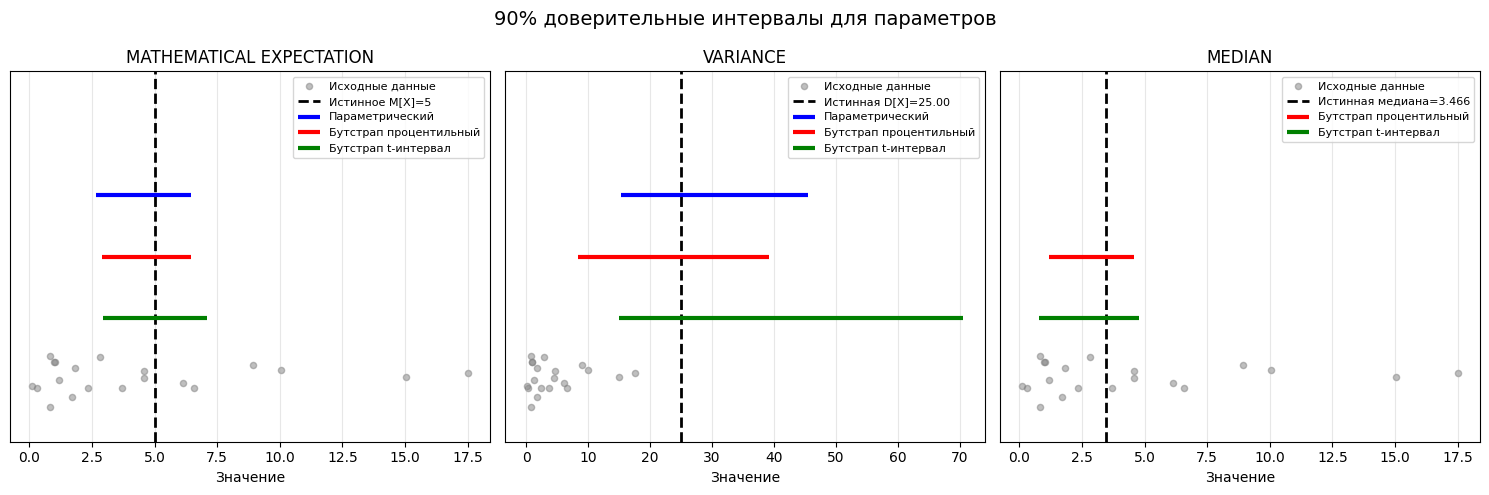

In [22]:

# Таблица для математического ожидания
df_mean = pd.DataFrame({
    "method CI": ["Параметрический (t-интервал)", "Бутстрап процентильный", "Бутстрап t-интервал"],
    "(a, b) of 90% CI": [
        f"({param_lower_mean:.4f}, {param_upper_mean:.4f})",
        f"({perc_lower_mean:.4f}, {perc_upper_mean:.4f})",
        f"({t_lower_mean:.4f}, {t_upper_mean:.4f})"
    ],
    "CI_width": [param_width_mean, perc_width_mean, t_width_mean]
})

# Таблица для дисперсии
df_var = pd.DataFrame({
    "method CI": ["Параметрический (χ²-интервал)", "Бутстрап процентильный", "Бутстрап t-интервал"],
    "(a, b) of 90% CI": [
        f"({param_lower_var:.4f}, {param_upper_var:.4f})",
        f"({perc_lower_var:.4f}, {perc_upper_var:.4f})",
        f"({t_lower_var:.4f}, {t_upper_var:.4f})"
    ],
    "CI_width": [param_width_var, perc_width_var, t_width_var]
})

# Таблица для медианы
df_median = pd.DataFrame({
    "method CI": ["Бутстрап процентильный", "Бутстрап t-интервал"],
    "(a, b) of 90% CI": [
        f"({perc_lower_median:.4f}, {perc_upper_median:.4f})",
        f"({t_lower_median:.4f}, {t_upper_median:.4f})"
    ],
    "CI_width": [perc_width_median, t_width_median]
})

print("\nТаблица для MEAN:")
print(df_mean.to_string(index=False))

print("\nТаблица для VAR:")
print(df_var.to_string(index=False))

print("\nТаблица для MEDIAN:")
print(df_median.to_string(index=False))


# Истинные значения параметров
true_mean = M_X
true_var = (1/lambd)**2
true_median = np.log(2) / lambd

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График для среднего
ax = axes[0]
y_jitter = np.random.normal(0, 0.02, len(sample))
ax.scatter(sample, y_jitter, alpha=0.5, s=20, color='gray', label='Исходные данные')
ax.axvline(true_mean, color='black', linestyle='--', linewidth=2, label=f'Истинное M[X]={true_mean}')
ax.hlines(y=0.3, xmin=param_lower_mean, xmax=param_upper_mean, colors='blue', linewidth=3, label='Параметрический')
ax.hlines(y=0.2, xmin=perc_lower_mean, xmax=perc_upper_mean, colors='red', linewidth=3, label='Бутстрап процентильный')
ax.hlines(y=0.1, xmin=t_lower_mean, xmax=t_upper_mean, colors='green', linewidth=3, label='Бутстрап t-интервал')
ax.set_title('MATHEMATICAL EXPECTATION')
ax.set_xlabel('Значение')
ax.set_ylim(-0.1, 0.5)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# График для дисперсии
ax = axes[1]
ax.scatter(sample, y_jitter, alpha=0.5, s=20, color='gray', label='Исходные данные')
ax.axvline(true_var, color='black', linestyle='--', linewidth=2, label=f'Истинная D[X]={true_var:.2f}')
ax.hlines(y=0.3, xmin=param_lower_var, xmax=param_upper_var, colors='blue', linewidth=3, label='Параметрический')
ax.hlines(y=0.2, xmin=perc_lower_var, xmax=perc_upper_var, colors='red', linewidth=3, label='Бутстрап процентильный')
ax.hlines(y=0.1, xmin=t_lower_var, xmax=t_upper_var, colors='green', linewidth=3, label='Бутстрап t-интервал')
ax.set_title('VARIANCE')
ax.set_xlabel('Значение')
ax.set_ylim(-0.1, 0.5)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# График для медианы
ax = axes[2]
ax.scatter(sample, y_jitter, alpha=0.5, s=20, color='gray', label='Исходные данные')
ax.axvline(true_median, color='black', linestyle='--', linewidth=2, label=f'Истинная медиана={true_median:.3f}')
ax.hlines(y=0.2, xmin=perc_lower_median, xmax=perc_upper_median, colors='red', linewidth=3, label='Бутстрап процентильный')
ax.hlines(y=0.1, xmin=t_lower_median, xmax=t_upper_median, colors='green', linewidth=3, label='Бутстрап t-интервал')
ax.set_title('MEDIAN')
ax.set_xlabel('Значение')
ax.set_ylim(-0.1, 0.5)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('90% доверительные интервалы для параметров', fontsize=14)
plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=150)
plt.show()


# задание 3: Влияние параметра B на доверительный интервал

## 1. Что такое параметр B в бутстрапе

**B (number of bootstrap replicates)** — это количество генерируемых бутстрап-выборок (псевдовыборок) из исходной выборки.

В базовом алгоритме бутстрапа:
1. Из исходной выборки объёма n генерируется **B** псевдовыборок (каждая объёмом n, с возвращением)
2. Для каждой псевдовыборки вычисляется интересующая статистика $\hat{\theta}^{*b}$
3. Получается набор $\{\hat{\theta}^{*1}, \hat{\theta}^{*2}, ..., \hat{\theta}^{*B}\}$ — **эмпирическое бутстрап-распределение** статистики

## 2. Как B влияет на точность оценок

### 2.1. Теоретический аспект

При $B \to \infty$ эмпирическое бутстрап-распределение стремится к истинному бутстрап-распределению:

$$\lim_{B \to \infty} \hat{F}_B^*(\theta^*) = F^*(\theta^*)$$

где:
- $\hat{F}_B^*$ — эмпирическая функция распределения, построенная по B бутстрап-реализациям
- $F^*$ — истинное бутстрап-распределение (при бесконечном количестве псевдовыборок)

**Важно:** При увеличении B **уменьшается случайная ошибка** (simulation error), связанная с конечным числом бутстрап-повторений. Однако B **не влияет** на систематическую ошибку (bias) бутстрап-оценки.

### 2.2. Ошибка аппроксимации

При конечном B мы заменяем истинное распределение $F^*$ на эмпирическое $\hat{F}_B^*$. Ошибка этой аппроксимации имеет порядок:

$$\text{Ошибка} \propto \frac{1}{\sqrt{B}}$$

Это означает, что:
- При увеличении B в 100 раз, ошибка уменьшается в 10 раз
- Увеличение B даёт убывающую отдачу (diminishing returns)

## 3. Влияние B на доверительный интервал

### 3.1. На границы интервала

При малых B (например, B = 10, 50):
- Границы доверительного интервала **нестабильны** — при повторном запуске могут сильно меняться
- Квантили $\hat{\theta}^*_{(\alpha/2)}$ и $\hat{\theta}^*_{(1-\alpha/2)}$ оцениваются грубо
- Интервал может быть "рваным" из-за малого количества точек для определения процентилей

При больших B (например, B = 1000, 5000):
- Границы **стабилизируются** — стремятся к своим истинным значениям
- Квантили оцениваются более точно
- Интервал становится "гладким"

### 3.2. На ширину интервала

Ширина доверительного интервала также стабилизируется с ростом B:

$$\text{Width}(CI) \xrightarrow{B \to \infty} \text{Width}_{\text{истинное}}$$

При малых B ширина может:
- Сильно колебаться от запуска к запуску
- Быть завышенной или заниженной

В задании 3 требуется построить график:
- **По оси X** — $\log(B)$ (логарифм числа бутстрап-повторений)
- **По оси Y** — оценка стандартной ошибки или границы доверительного интервала

**Характерные особенности:**
1. При малых B (log(B) ≈ 2.3 для B=10) — сильные колебания
2. При средних B (log(B) ≈ 4.6 для B=100) — колебания уменьшаются
3. При больших B (log(B) ≈ 6.9 для B=1000, 8.5 для B=5000, 9.2 для B=10000) — график выходит на плато (стабилизация)

## 6. Почему используется log(B)?

Использование $\log(B)$ вместо B связано с тем, что:
1. Зависимость точности от B имеет вид $1/\sqrt{B}$, что на линейной шкале даёт слишком быстрое падение
2. Логарифмическая шкала позволяет наглядно показать изменения во всём диапазоне B (от 10 до 10000)
3. Убывающая отдача (diminishing returns) лучше видна на логарифмической шкале


**Наблюдения:**
- Между B=10 и B=100 — значительные изменения
- Между B=1000 и B=5000 — изменения незначительные
- Между B=5000 и B=10000 — практически нет изменений (стабилизация)


При выполнении задания 3 необходимо:
1. Взять B ∈ [10, 100, 1000, 5000, 10000]
2. Для каждого B построить доверительный интервал (например, для медианы)
3. Построить график зависимости границ интервала и его ширины от log(B)
4. Продемонстрировать, что при B ≥ 1000 происходит стабилизация оценок


Обработка B = 10...
B =    10: 90% ДИ = (1.9081, 5.8051), ширина = 3.8969
Обработка B = 100...
B =   100: 90% ДИ = (1.4548, 5.1621), ширина = 3.7073
Обработка B = 1000...
B =  1000: 90% ДИ = (1.3623, 4.5954), ширина = 3.2332
Обработка B = 5000...
B =  5000: 90% ДИ = (1.3671, 4.5954), ширина = 3.2283
Обработка B = 10000...
B = 10000: 90% ДИ = (1.1934, 4.5954), ширина = 3.4020


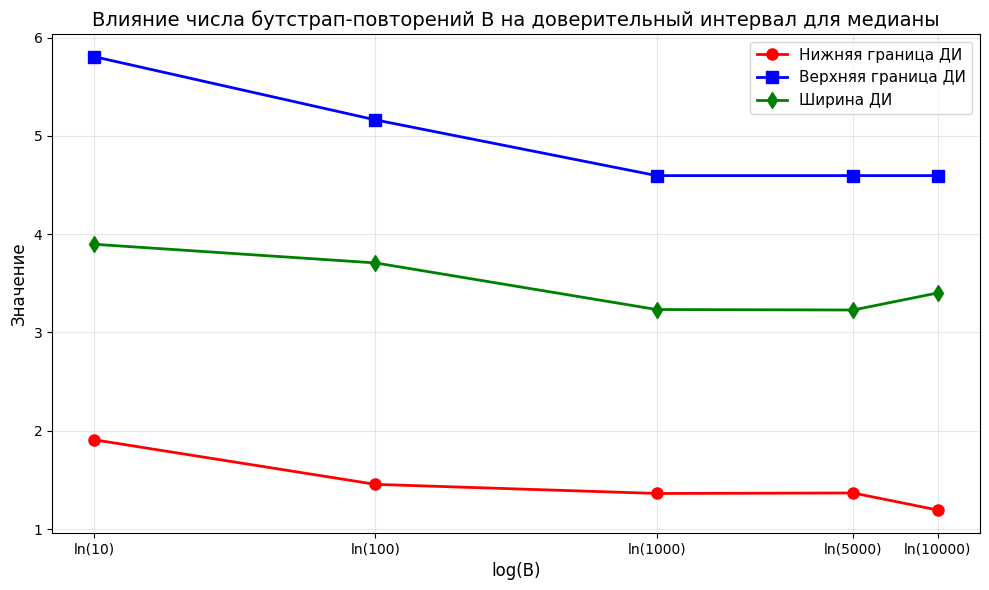

In [ ]:

B_values = [10, 100, 1000, 5000, 10000]
log_B = np.log(B_values)

ci_lower = []
ci_upper = []
ci_width = []

for B_val in B_values:
    print(f"Обработка B = {B_val}...")
    
    # Генерация бутстрап-выборок и вычисление медиан (как в задании 2)
    boot_medians = []
    for b in range(B_val):
        boot_sample = np.random.choice(sample, size=n, replace=True)
        boot_medians.append(np.median(boot_sample))
    boot_medians = np.array(boot_medians)
    
    # Процентильный доверительный интервал
    lower = np.percentile(boot_medians, 100 * alpha/2)
    upper = np.percentile(boot_medians, 100 * (1 - alpha/2))
    
    ci_lower.append(lower)
    ci_upper.append(upper)
    ci_width.append(upper - lower)
    print(f"B = {B_val:5d}: 90% ДИ = ({lower:.4f}, {upper:.4f}), ширина = {upper-lower:.4f}")

# Построение графика
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(log_B, ci_lower, 'o-', color='red', label='Нижняя граница ДИ', linewidth=2, markersize=8)
ax.plot(log_B, ci_upper, 's-', color='blue', label='Верхняя граница ДИ', linewidth=2, markersize=8)
ax.plot(log_B, ci_width, 'd-', color='green', label='Ширина ДИ', linewidth=2, markersize=8)
ax.set_xlabel('log(B)', fontsize=12)
ax.set_ylabel('Значение', fontsize=12)
ax.set_title('Влияние числа бутстрап-повторений B на доверительный интервал для медианы', fontsize=14)
ax.set_xticks(log_B)
ax.set_xticklabels([f'ln({B})' for B in B_values])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 4: Анализ бутстрап-распределений и проверка гипотезы о нормальности (по материалам презентаций)

## 1. Бутстрап-реализации и их распределения

В задании 4 рассматриваются два типа бутстрап-реализаций, полученных при вычислении доверительного интервала для медианы:

### 1.1. Реализации $\{\hat{\theta}^{*1}, \hat{\theta}^{*2}, ..., \hat{\theta}^{*B}\}$

Это набор значений статистики (медианы), вычисленных по каждой бутстрап-выборке.

**Как получаются:**
1. Из исходной выборки $X = \{x_1, ..., x_n\}$ генерируется бутстрап-выборка $X^{*b}$ (выборка с возвращением)
2. Вычисляется медиана этой выборки: $\hat{\theta}^{*b} = \text{median}(X^{*b})$
3. Процесс повторяется $B$ раз (в работе $B = 1000$)

**Что представляет собой это распределение:**
- Это **эмпирическое бутстрап-распределение** статистики $\hat{\theta}$ (медианы)
- Оно аппроксимирует истинное распределение выборочной медианы
- Позволяет оценить изменчивость (вариабельность) оценки

### 1.2. Реализации $\{T^{*1}, T^{*2}, ..., T^{*B}\}$

Это набор **стьюдентизированных** (нормированных) значений статистики.

**Определение:**
$$T^{*b} = \frac{\hat{\theta}^{*b} - \hat{\theta}}{\widehat{SE}^{*b}}$$

где:
- $\hat{\theta}^{*b}$ — значение статистики на бутстрап-выборке
- $\hat{\theta}$ — значение статистики на исходной выборке
- $\widehat{SE}^{*b}$ — оценка стандартной ошибки, вычисленная по той же бутстрап-выборке

**Для медианы особенность:**
Стандартная ошибка медианы не имеет простой аналитической формулы. Поэтому $\widehat{SE}^{*b}$ оценивается с помощью **вложенного (двойного) бутстрапа**:
1. Для каждой бутстрап-выборки $X^{*b}$ генерируется $B_{in}$ внутренних псевдовыборок
2. Вычисляются медианы этих внутренних выборок
3. $\widehat{SE}^{*b}$ = стандартное отклонение этих внутренних медиан

## 2. Эмпирическая функция распределения (ECDF)

### 2.1. Определение (по презентации, слайд 25)

Эмпирическая функция распределения $\hat{F}_n(x)$ для выборки $\{x_1, x_2, ..., x_n\}$ определяется как:

$$\hat{F}_n(x) = \begin{cases} 
0, & x < x_{(1)} \\
\frac{i}{n}, & x_{(i)} \leq x < x_{(i+1)}, \quad i = 1 \dots (n-1) \\
1, & x \geq x_{(n)}
\end{cases}$$

где $x_{(1)} \leq x_{(2)} \leq ... \leq x_{(n)}$ — упорядоченная выборка (вариационный ряд).

### 2.2. Свойства ECDF (из презентации, слайд 24)

- **Теорема Гливенко:** $\hat{F}_n(x; \theta) \xrightarrow{p} F(x)$ при $n \to \infty$
- Эмпирическая функция распределения является **состоятельной оценкой** теоретической функции распределения
- Если гипотеза о виде распределения верна, то различия между $\hat{F}_n(x)$ и $F(x)$ должны убывать с увеличением $n$

### 2.3. Построение ECDF для бутстрап-реализаций

Для набора $\{\hat{\theta}^{*1}, ..., \hat{\theta}^{*B}\}$ ECDF строится следующим образом:

1. Упорядочиваем значения по возрастанию: $\hat{\theta}^{*}_{(1)} \leq \hat{\theta}^{*}_{(2)} \leq ... \leq \hat{\theta}^{*}_{(B)}$
2. Для каждого упорядоченного значения:
   $$\hat{F}_B(\hat{\theta}^{*}_{(i)}) = \frac{i}{B}$$


## 4. Критерий согласия Колмогорова для проверки нормальности

### 4.1. Общие положения (по презентации, слайд 24)

Критерий Колмогорова основан на теореме Гливенко и используется для проверки гипотезы о виде закона распределения.

**Основная идея:** Если гипотеза о виде распределения верна, то должно проявляться сходство между эмпирической и теоретической функциями распределения, и различия между ними должны убывать с увеличением $n$.

### 4.2. Статистика критерия Колмогорова (слайд 24)

$$D_n = \max_{|x| < \infty} |\hat{F}_n(x; \theta) - F(x; \theta)|$$

где:
- $\hat{F}_n(x; \theta)$ — эмпирическая функция распределения
- $F(x; \theta)$ — теоретическая функция распределения

### 4.3. Распределение Колмогорова (слайд 24)

Если гипотеза верна и проверяемый закон распределения — непрерывный, то:

$$Z = \sqrt{n} D_n \in K \text{ (распределение Колмогорова)}$$

### 4.4. Критические значения (слайд 24)

Для распределения Колмогорова составлены таблицы процентных точек (критических значений):

| Уровень значимости $\alpha$ | 0.20 | 0.10 | 0.05 | 0.02 | 0.01 | 0.001 |
|-----------------------------|------|------|------|------|------|-------|
| **$\lambda_{\alpha}$** | 1.073 | 1.224 | 1.358 | 1.520 | 1.627 | 1.950 |

### 4.5. Правило принятия решения

$H_0$ (гипотеза о нормальности распределения) **принимается**, если $Z < \lambda_{\alpha}$

$H_0$ **отвергается**, если $Z \geq \lambda_{\alpha}$

### 4.6. Ограничения критерия Колмогорова (слайд 24)

> "Критерий Колмогорова применим для непрерывных случайных величин (генеральных совокупностей) + выборка достаточно большого размера (примерно $n > 50$)"

В нашем случае для бутстрап-реализаций $B = 1000$, что значительно больше 50, поэтому критерий применим.

## 5. Алгоритм проверки гипотезы о нормальности по критерию Колмогорова (слайд 25)

Для сложной гипотезы (когда параметры распределения неизвестны) используется следующий алгоритм:

### Шаг 1. Оценка параметров закона распределения

По выборочным данным $x_1, x_2, ..., x_n$ (в нашем случае — бутстрап-реализации) строим оценки параметров нормального закона распределения:

- Оценка математического ожидания: $\hat{\mu} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$
- Оценка среднеквадратического отклонения: $\hat{\sigma} = s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$

### Шаг 2. Построение эмпирической функции распределения

Строится вариационный ряд и определяется эмпирическая функция распределения $\hat{F}_n(x)$.

### Шаг 3. Вычисление статистики Колмогорова

$$D_n = \max_{i \in [1 \dots n]} |\hat{F}_n(x_i) - F(x_i; \hat{\mu}, \hat{\sigma})|$$

где $F(x; \hat{\mu}, \hat{\sigma})$ — функция нормального распределения с оценёнными параметрами.

### Шаг 4. Вычисление $Z = \sqrt{n} D_n$

### Шаг 5. Сравнение с критическим значением

Значение $Z$ сравнивается с критическим $\lambda_{\alpha}$ для выбранного уровня значимости $\alpha$.

### Шаг 6. Принятие решения

- Если $Z < \lambda_{\alpha}$ → $H_0$ принимается (распределение не противоречит нормальному)
- Если $Z \geq \lambda_{\alpha}$ → $H_0$ отвергается (распределение отличается от нормального)


## 7. Особенность для сложной гипотезы (слайд 25)

В презентации указано:

> "Для сложной гипотезы, т.е. когда не известны значения параметров... $D_n$ распределена иначе и для нее необходима новая таблица + нет свойства независимости от закона распределения. Для практически важных распределений (нормальное, показательное) составлены таблицы."

Поэтому для проверки нормальности бутстрап-реализаций мы используем модифицированный критерий Колмогорова с оценёнными параметрами.


Для бутстрап-реализаций $\{\hat{\theta}^{*1}, ..., \hat{\theta}^{*B}\}$ и $\{T^{*1}, ..., T^{*B}\}$:

### 9.1. Построение эмпирических функций и плотностей

1. **Построить гистограммы** эмпирических плотностей распределения (слайд 21 — про гистограммы в контексте критерия Хи-квадрат)
2. **Построить эмпирические функции распределения (ECDF)** (слайд 25)

### 9.2. Проверка гипотезы о нормальности

Используя критерий Колмогорова (слайды 24-26):

1. Вычислить $D_n = \max |\hat{F}_B(x) - F_{norm}(x; \hat{\mu}, \hat{\sigma})|$
2. Вычислить $Z = \sqrt{B} \cdot D_n$
3. Сравнить с $\lambda_{\alpha}$ из таблицы (например, при $\alpha = 0.05$, $\lambda_{\alpha} = 1.358$)
4. Сделать вывод о нормальности распределения

## 10. Итоговая таблица критических значений

Для выполнения задания 4 необходимо использовать следующую таблицу (слайд 24):

| $\alpha$ | 0.20 | 0.10 | 0.05 | 0.02 | 0.01 | 0.001 |
|----------|------|------|------|------|------|-------|
| $\lambda_{\alpha}$ | 1.073 | 1.224 | 1.358 | 1.520 | 1.627 | 1.950 |

 В лабораторной работе можно использовать уровень значимости $\alpha = 0.05$, тогда критическое значение $\lambda_{0.05} = 1.358$.


При выполнении задания 4 необходимо:
1. Построить гистограммы и ECDF для $\hat{\theta}^{*}$ (медианы) и $T^{*}$
2. Визуально оценить форму распределений
3. Провести **критерий Колмогорова** для проверки нормальности каждого распределения
4. Сравнить полученные значения $Z = \sqrt{n}D_n$ с критическими значениями $\lambda_{\alpha}$ из таблицы
5. Сделать заключение: являются ли полученные бутстрап-реализации нормально распределёнными

Генерация бутстрап-реализаций для медианы...
Вычисление T-статистик (требует двойного бутстрапа, может занять время)...
Исходная медиана θ̂ = 2.5870
Стандартная ошибка медианы ŜE = 1.2642
  Обработано 200 из 1000...
  Обработано 400 из 1000...
  Обработано 600 из 1000...
  Обработано 800 из 1000...
  Обработано 1000 из 1000...
Генерация завершена.

Построение графиков...


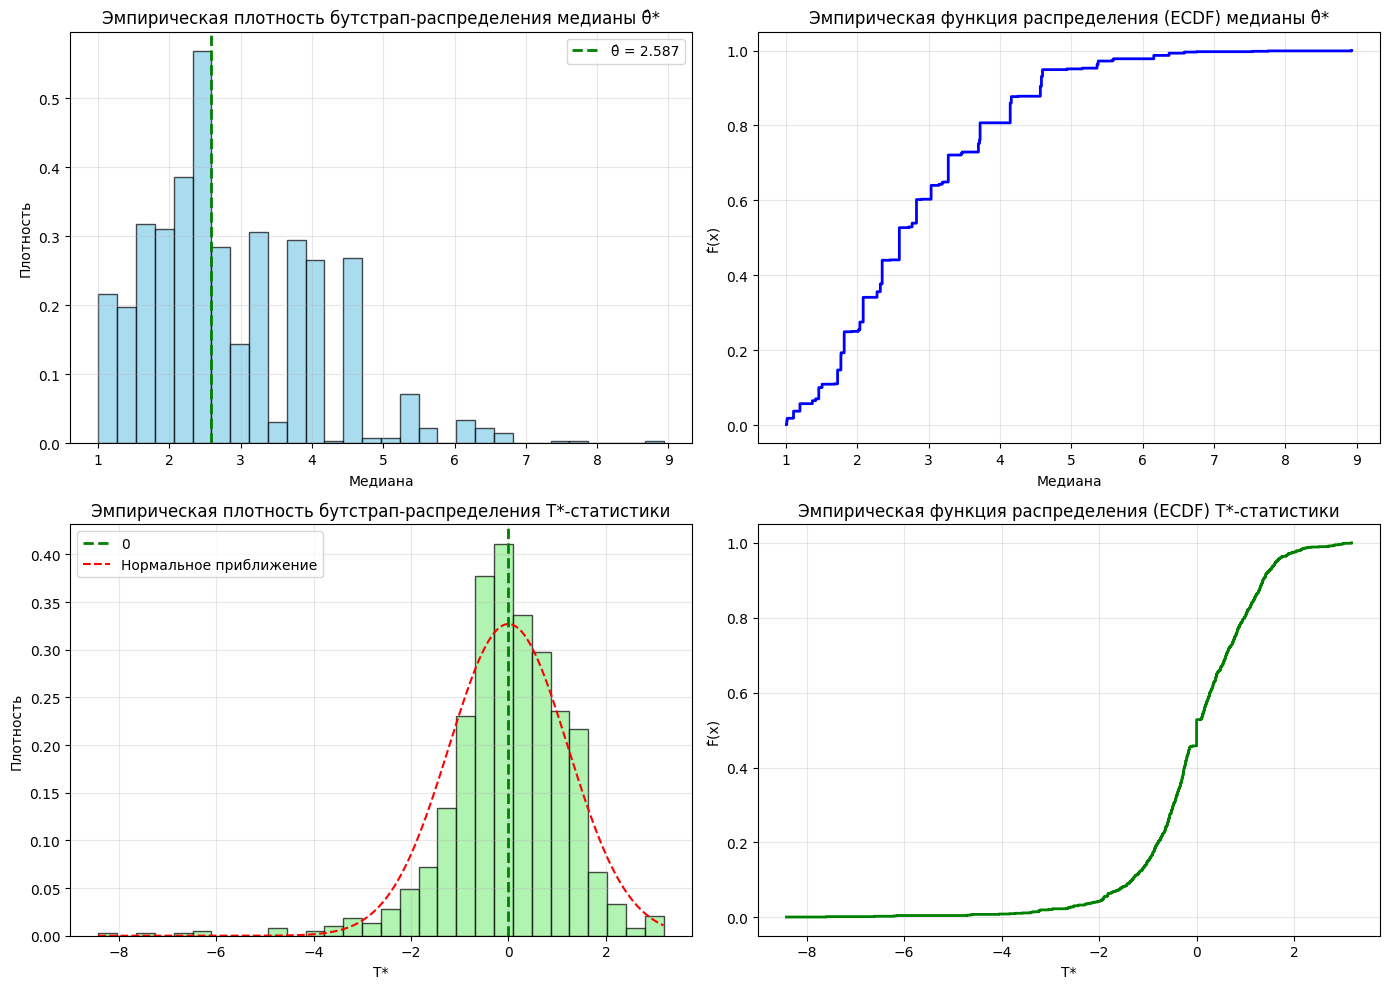

Критические значения λ_α из таблицы (слайд 24 презентации 7):
  α=0.2: λ=1.073
  α=0.1: λ=1.224
  α=0.05: λ=1.358
  α=0.02: λ=1.52
  α=0.01: λ=1.627
  α=0.001: λ=1.95

Проверка при уровне значимости α = 0.05

--- Бутстрап-распределение θ̂* (медиана) ---
  Объём выборки n = 1000
  Оценка μ̂ = 2.859501
  Оценка σ̂ = 1.197986
  Статистика Dn = 0.116965
  Z = √1000 · Dn = 3.698761
  Критическое значение λ_0.05 = 1.358
  Вывод: Z (3.6988) ≥ λ (1.358) → H0 ОТВЕРГАЕТСЯ
  → Распределение отличается от нормального
--- Бутстрап-распределение T* ---
  Объём выборки n = 1000
  Оценка μ̂ = -0.014548
  Оценка σ̂ = 1.220145
  Статистика Dn = 0.070944
  Z = √1000 · Dn = 2.243456
  Критическое значение λ_0.05 = 1.358
  Вывод: Z (2.2435) ≥ λ (1.358) → H0 ОТВЕРГАЕТСЯ
  → Распределение отличается от нормального
1. Бутстрап-распределение медианы (θ̂*): НЕ НОРМАЛЬНОЕ
2. Бутстрап-распределение T*-статистики: НЕ НОРМАЛЬНОЕ


In [25]:
# Задание 4: Анализ бутстрап-распределений для медианы

B_analysis = 1000  # количество бутстрап-выборок для анализа

# 4.1 Получение бутстрап-реализаций для медианы
print("Генерация бутстрап-реализаций для медианы...")
boot_medians = []
for b in range(B_analysis):
    boot_sample = np.random.choice(sample, size=n, replace=True)
    boot_medians.append(np.median(boot_sample))
boot_medians = np.array(boot_medians)

# Вычисление T-статистик для медианы (с двойным бутстрапом)
print("Вычисление T-статистик (требует двойного бутстрапа, может занять время)...")
theta_hat_med = np.median(sample)

# Оценка SE_hat для исходной выборки через внутренний бутстрап
B_inner = 200
inner_medians = []
for _ in range(B_inner):
    inner_sample = np.random.choice(sample, size=n, replace=True)
    inner_medians.append(np.median(inner_sample))
se_hat_med = np.std(inner_medians, ddof=1)

print(f"Исходная медиана θ̂ = {theta_hat_med:.4f}")
print(f"Стандартная ошибка медианы ŜE = {se_hat_med:.4f}")

# Генерация T* статистик
T_star_med = np.zeros(B_analysis)
for b in range(B_analysis):
    # Основная бутстрап-выборка
    boot_sample = np.random.choice(sample, size=n, replace=True)
    theta_star = np.median(boot_sample)
    
    # Внутренний бутстрап для оценки SE*
    inner_medians_b = []
    for _ in range(B_inner):
        inner_sample_b = np.random.choice(boot_sample, size=n, replace=True)
        inner_medians_b.append(np.median(inner_sample_b))
    se_star = np.std(inner_medians_b, ddof=1)
    
    if se_star > 0:
        T_star_med[b] = (theta_star - theta_hat_med) / se_star
    else:
        T_star_med[b] = 0
    
    # Вывод прогресса
    if (b + 1) % 200 == 0:
        print(f"  Обработано {b + 1} из {B_analysis}...")

print("Генерация завершена.")

# 4.2 Построение эмпирических функций и гистограмм
print("\nПостроение графиков...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Гистограмма для медианы
ax = axes[0, 0]
ax.hist(boot_medians, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(theta_hat_med, color='green', linestyle='--', linewidth=2, label=f'θ̂ = {theta_hat_med:.3f}')
ax.set_title('Эмпирическая плотность бутстрап-распределения медианы θ̂*')
ax.set_xlabel('Медиана')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(True, alpha=0.3)

# График 2: Эмпирическая функция распределения для медианы
ax = axes[0, 1]
sorted_med = np.sort(boot_medians)
ecdf_med = np.arange(1, len(sorted_med) + 1) / len(sorted_med)
ax.step(sorted_med, ecdf_med, where='post', color='blue', linewidth=2)
ax.set_title('Эмпирическая функция распределения (ECDF) медианы θ̂*')
ax.set_xlabel('Медиана')
ax.set_ylabel('F̂(x)')
ax.grid(True, alpha=0.3)

# График 3: Гистограмма для T-статистики
ax = axes[1, 0]
ax.hist(T_star_med, bins=30, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
ax.axvline(0, color='green', linestyle='--', linewidth=2, label='0')
# Добавим нормальное распределение для сравнения
x_norm = np.linspace(min(T_star_med), max(T_star_med), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, 0, np.std(T_star_med, ddof=1)), 'r--', linewidth=1.5, label='Нормальное приближение')
ax.set_title('Эмпирическая плотность бутстрап-распределения T*-статистики')
ax.set_xlabel('T*')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(True, alpha=0.3)

# График 4: Эмпирическая функция распределения для T-статистики
ax = axes[1, 1]
sorted_t = np.sort(T_star_med)
ecdf_t = np.arange(1, len(sorted_t) + 1) / len(sorted_t)
ax.step(sorted_t, ecdf_t, where='post', color='green', linewidth=2)
ax.set_title('Эмпирическая функция распределения (ECDF) T*-статистики')
ax.set_xlabel('T*')
ax.set_ylabel('F̂(x)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bootstrap_distributions.png', dpi=150)
plt.show()

# 4.3 Проверка нормальности по критерию Колмогорова

# Критические значения из презентации (слайд 24)
lambda_critical = {
    0.20: 1.073,
    0.10: 1.224,
    0.05: 1.358,
    0.02: 1.520,
    0.01: 1.627,
    0.001: 1.950
}

print("Критические значения λ_α из таблицы (слайд 24 презентации 7):")
for a, lam in lambda_critical.items():
    print(f"  α={a}: λ={lam}")
print()

def kolmogorov_normality_test(data, data_name, alpha=0.05):
    """
    Критерий согласия Колмогорова для проверки гипотезы о нормальности
    H0: распределение является нормальным
    H1: распределение не является нормальным
    """
    n = len(data)
    
    # Шаг 1: Оценка параметров нормального распределения
    mu_hat = np.mean(data)
    sigma_hat = np.std(data, ddof=1)
    
    # Шаг 2: Сортировка данных и построение эмпирической функции распределения
    data_sorted = np.sort(data)
    F_empirical = np.arange(1, n + 1) / n
    
    # Шаг 3: Вычисление теоретической функции нормального распределения
    F_theoretical = stats.norm.cdf(data_sorted, loc=mu_hat, scale=sigma_hat)
    
    # Шаг 4: Вычисление статистики Dn = max|F_теор - F_эмп|
    Dn = np.max(np.abs(F_theoretical - F_empirical))
    
    # Шаг 5: Вычисление Z = √n * Dn
    Z = np.sqrt(n) * Dn
    
    # Шаг 6: Сравнение с критическим значением
    lambda_crit = lambda_critical.get(alpha, 1.358)
    
    # Вывод результатов
    print(f"--- {data_name} ---")
    print(f"  Объём выборки n = {n}")
    print(f"  Оценка μ̂ = {mu_hat:.6f}")
    print(f"  Оценка σ̂ = {sigma_hat:.6f}")
    print(f"  Статистика Dn = {Dn:.6f}")
    print(f"  Z = √{n} · Dn = {Z:.6f}")
    print(f"  Критическое значение λ_{alpha} = {lambda_crit}")
    
    if Z < lambda_crit:
        print(f"  Вывод: Z ({Z:.4f}) < λ ({lambda_crit}) → H0 ПРИНИМАЕТСЯ")
        print("  → Распределение не противоречит нормальному")
        return True
    else:
        print(f"  Вывод: Z ({Z:.4f}) ≥ λ ({lambda_crit}) → H0 ОТВЕРГАЕТСЯ")
        print("  → Распределение отличается от нормального")
        return False

# Выбор уровня значимости
alpha_test = 0.05
print(f"Проверка при уровне значимости α = {alpha_test}\n")

# Проверка нормальности для бутстрап-распределения медианы
is_normal_med = kolmogorov_normality_test(boot_medians, "Бутстрап-распределение θ̂* (медиана)", alpha_test)

# Проверка нормальности для T-статистики
is_normal_t = kolmogorov_normality_test(T_star_med, "Бутстрап-распределение T*", alpha_test)

print(f"1. Бутстрап-распределение медианы (θ̂*): {'НОРМАЛЬНОЕ' if is_normal_med else 'НЕ НОРМАЛЬНОЕ'}")
print(f"2. Бутстрап-распределение T*-статистики: {'НОРМАЛЬНОЕ' if is_normal_t else 'НЕ НОРМАЛЬНОЕ'}")

